### 第 1 章 强化学习入门

#### 1.1 强化学习概述

强化学习讨论的是智能体怎么在复杂的、不确定性的环境里面最大化他的奖励。

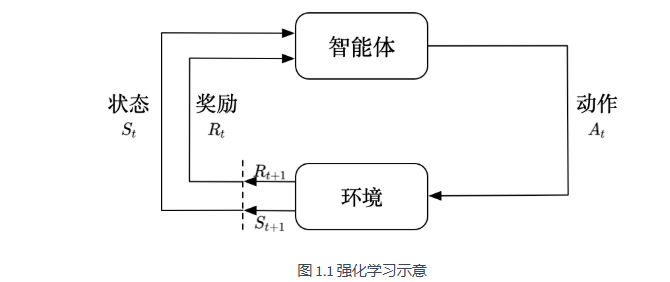

##### 1.1.1 强化学习与监督学习的区别

**监督学习**：从标注数据中学习输入到输出的映射 $f: \mathcal{X} \rightarrow \mathcal{Y}$

**强化学习**：智能体通过与环境交互，学习最优策略以最大化累积奖励

| 特性 | 监督学习 | 强化学习 |
|------|---------|---------|
| 数据来源 | 静态数据集 | 与环境交互 |
| 反馈形式 | 标签（正确答案） | 奖励信号（标量） |
| 学习目标 | 最小化预测误差 | 最大化累积奖励 |
| 决策序列 | 独立同分布 | 时序相关 |

##### 1.1.2 强化学习的核心要素

**五元组** $(\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$：

- $\mathcal{S}$：**状态空间**（State Space）：状态是对世界的描述，不会隐藏世界的信息，观测是对状态的部分描述，可能会遗漏一些信息。当智能体能够完全观测到环境的所有状态的时候，这个环境叫做完全可观测

- $\mathcal{A}$：**动作空间**（Action space）：在给定的环境中，有效的动作集合被叫做动作空间，动作空间分为离散动作空间和连续动作空间。

- $\mathcal{P}$：**状态转移概率**（Transition probability）

$$\mathcal{P}(s'|s,a) = P(S_{t+1}=s' | S_t=s, A_t=a)$$

- $\mathcal{R}$：**奖励函数**（Reward function）

$$\mathcal{R}(s,a) = \mathbb{E}[r_{t+1} | S_t=s, A_t=a]$$

我们当前采取了某个动作，可以得到多大的奖励。

在强化学习马尔可夫决策过程（MDP）的标准定义中，奖励函数（$\mathcal{R}$）和即时奖励（$r_{t+1}$）的核心区别，是「确定性的期望统计量」和「单次随机的实际奖励值」的区别

【1】即时奖励是一个随机变量，代表「$t$ 时刻在状态 $s$ 执行动作 $a$ 后，$t+1$ 时刻环境实际返回的、单次采样的奖励数值」。

**随机性来源**：MDP 的状态转移是随机的（由转移概率 $p$ 决定），同一个 $(s,a)$，可能转移到不同的下一状态 $s'$，对应得到的即时奖励 $r$ 也可能不同。

【2】奖励函数它是确定性的函数映射，是给定 $(s,a)$ 条件下，即时奖励 $r_{t+1}$ 的条件数学期望。

**核心含义**：输入是当前状态 $s$ 和动作 $a$，输出是一个固定的、统计平均后的期望奖励值，描述的是「在 $s$ 状态做 $a$ 动作，平均能拿到多少奖励」。

**公式展开**：结合转移概率，它的完整计算式为

$$R(s,a)=\sum_{s'}P(s'|s,a) \cdot r(s,a,s')$$

其中 $r(s,a,s')$ 是从 $s$ 执行 $a$ 转移到 $s'$ 的即时奖励，本质就是对所有可能的 $r$ 值，按出现概率加权平均。

- $\gamma$：**折扣因子**（Discount factor），$\gamma \in [0,1]$

**智能体的核心组成部分**： 

- **策略**：智能体会用策略来选择下一步的动作，策略分为随机性策略和确定性策略。
  - **随机性策略**：输入一个状态，输出一个概率。这个概率是智能体所有动作的概率，然后对这个概率分布进行采样，可得到智能体将采取的动作。比如可能是有 0.7 的概率往左，0.3 的概率往右，那么通过采样就可以得到智能体将采取的动作。
  - **确定性策略**：就是智能体直接采取最有可能的动作

- **价值函数**：用价值函数来对当前状态进行评估，价值函数用于评估智能体进入某个状态后，可以对后面的奖励带来多大的影响。价值函数越大，智能体进入这个状态越有利。

价值函数是对未来奖励的预测。我们用它来评估状态的好坏

**状态价值函数**：

$$V_{\pi}(s) \doteq \mathbb{E}_{\pi}\left[ G_t \mid s_t=s\right] = \mathbb{E}_{\pi}\left[ \sum_{k=0}^{\infty} \gamma^k r_{t+k+1} \mid s_t=s\right], \forall s \in \mathcal{S}$$

**状态-动作价值函数**：表明未来可以获得奖励的期望取决于当前的状态和当前的动作

$$Q_{\pi}(s, a)  \doteq \mathbb{E}_{\pi}\left[ G_t \mid s_t=s, a_t =a\right] = \mathbb{E}_{\pi}\left[ \sum_{k=0}^{\infty} \gamma^k r_{t+k+1} \mid s_t=s, a_t = a\right], \forall s \in \mathcal{S}, \forall a \in \mathcal{A}$$

- **模型**：模型表示智能体对环境状态的理解。决定了环境中世界的运行方式

模型决定了下一步的状态，下一步的状态取决于当前的状态以及当前采取的动作。模型由状态转移概率和奖励函数构成

**状态转移概率**： 

$$\mathcal{P}_{ss'}^{a} = \mathcal{P}(s_{t+1} = s' \mid s_t=s, a_t=a)$$

**奖励函数**: 当前状态采取了某个动作，可以得到多大的奖励。

$$\mathcal{R}(s,a)=\mathbb{E}\left[ r_{t+1} \mid s_t=s, a_t=a\right]$$

有了策略，价值函数、模型三个组成部分后，就形成了一个马尔可夫决策过程
